In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%config InlineBackend.figure_format = 'retina'

In [34]:
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.titlesize"] = 18

In [35]:
RANDOM_SEED = 666
np.random.seed(RANDOM_SEED)

In [36]:
#No matter how many times you run the program after this, as long as you use np.random.seed(42), 
#you’ll always get the same sequence of random numbers
print(np.random.randint(1, 100, 5)) 

[ 3 46 31 63 71]


### Train /Test Split for Imbalanced
#### Think that we have a binary classification problem and 99% of data belongs to negative class and 1% belongs to positive class

In [38]:
N = 1_000
y = np.zeros(N)
positive_indices = np.random.choice(np.arange(N),10,replace=False)
y[positive_indices] = 1

In [39]:
print(y.mean())

0.01


In [40]:
from sklearn.model_selection import train_test_split

In [43]:
print("class balance")
print("---------------")
for simulation in range(1,11):
    train, test = train_test_split(y,test_size=0.20,random_state=simulation)
    train_class_balance = train.mean()
    test_class_balance = test.mean()
    print(
    f" (Simulation {simulation:2d})"
    f" Train {train_class_balance:.2%}"
    f" Test {test_class_balance:.2%}"
    )

class balance
---------------
 (Simulation  1) Train 1.25% Test 0.00%
 (Simulation  2) Train 1.12% Test 0.50%
 (Simulation  3) Train 1.12% Test 0.50%
 (Simulation  4) Train 1.00% Test 1.00%
 (Simulation  5) Train 0.75% Test 2.00%
 (Simulation  6) Train 1.12% Test 0.50%
 (Simulation  7) Train 0.88% Test 1.50%
 (Simulation  8) Train 1.00% Test 1.00%
 (Simulation  9) Train 1.00% Test 1.00%
 (Simulation 10) Train 0.75% Test 2.00%


In [44]:
print("Stratified class balance")
print("--------------------")
for simulation in range(1,11):
    train, test = train_test_split(y,test_size=0.20, random_state = simulation, stratify=y )
    train_class_balance = train.mean()
    test_class_balance = test.mean()
    print(
        f"(Simulation {simulation:2d}) "
        f"Train: {train_class_balance:.2%}"
        f", Test: {test_class_balance:.2%}"
    )

Stratified class balance
--------------------
(Simulation  1) Train: 1.00%, Test: 1.00%
(Simulation  2) Train: 1.00%, Test: 1.00%
(Simulation  3) Train: 1.00%, Test: 1.00%
(Simulation  4) Train: 1.00%, Test: 1.00%
(Simulation  5) Train: 1.00%, Test: 1.00%
(Simulation  6) Train: 1.00%, Test: 1.00%
(Simulation  7) Train: 1.00%, Test: 1.00%
(Simulation  8) Train: 1.00%, Test: 1.00%
(Simulation  9) Train: 1.00%, Test: 1.00%
(Simulation 10) Train: 1.00%, Test: 1.00%


### Stratification Reduces Model Selection Error

In [45]:
from sklearn.datasets import make_classification

In [46]:
# Make a fake imbalanced classification dataset
X, y = make_classification(
    n_samples=10_000, n_features=50, n_classes=2, weights=[0.99, 0.01]
)

In [47]:
# We will eventually split into train, validation, and test.
# To start, we split off a test set.
X_pretrain, X_test, y_pretrain, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

#### lets run a simulation. For each simulation, we randomly split the data into training and validation sets
#### and train a logistic regression model on training data
#### Ideally, the performance on our validation set should match the performance on test set
#### We'll keep track of the validation and test 𝐹1 scores for each simulation and then calculate the difference between them. We'll do this for both stratified and non-stratified sampling.

In [50]:
N_sim = 200

val_f1s = []
test_f1s = []
for sim in range(N_sim):
    X_train, X_val, y_train, y_val = train_test_split(
        X_pretrain, y_pretrain, test_size=0.20, random_state=sim
    )
    model = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced")
    model.fit(X_train, y_train)
    val_f1s.append(f1_score(y_val, model.predict(X_val)))
    test_f1s.append(f1_score(y_test, model.predict(X_test)))

no_stratify_diffs = np.array(test_f1s) - np.array(val_f1s)

val_f1s = []
test_f1s = []
for sim in range(N_sim):
    X_train, X_val, y_train, y_val = train_test_split(
        X_pretrain, y_pretrain, test_size=0.20, random_state=sim, stratify=y_pretrain
    )
    model = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced")
    model.fit(X_train, y_train)
    val_f1s.append(f1_score(y_val, model.predict(X_val)))
    test_f1s.append(f1_score(y_test, model.predict(X_test)))

stratify_diffs = np.array(test_f1s) - np.array(val_f1s)

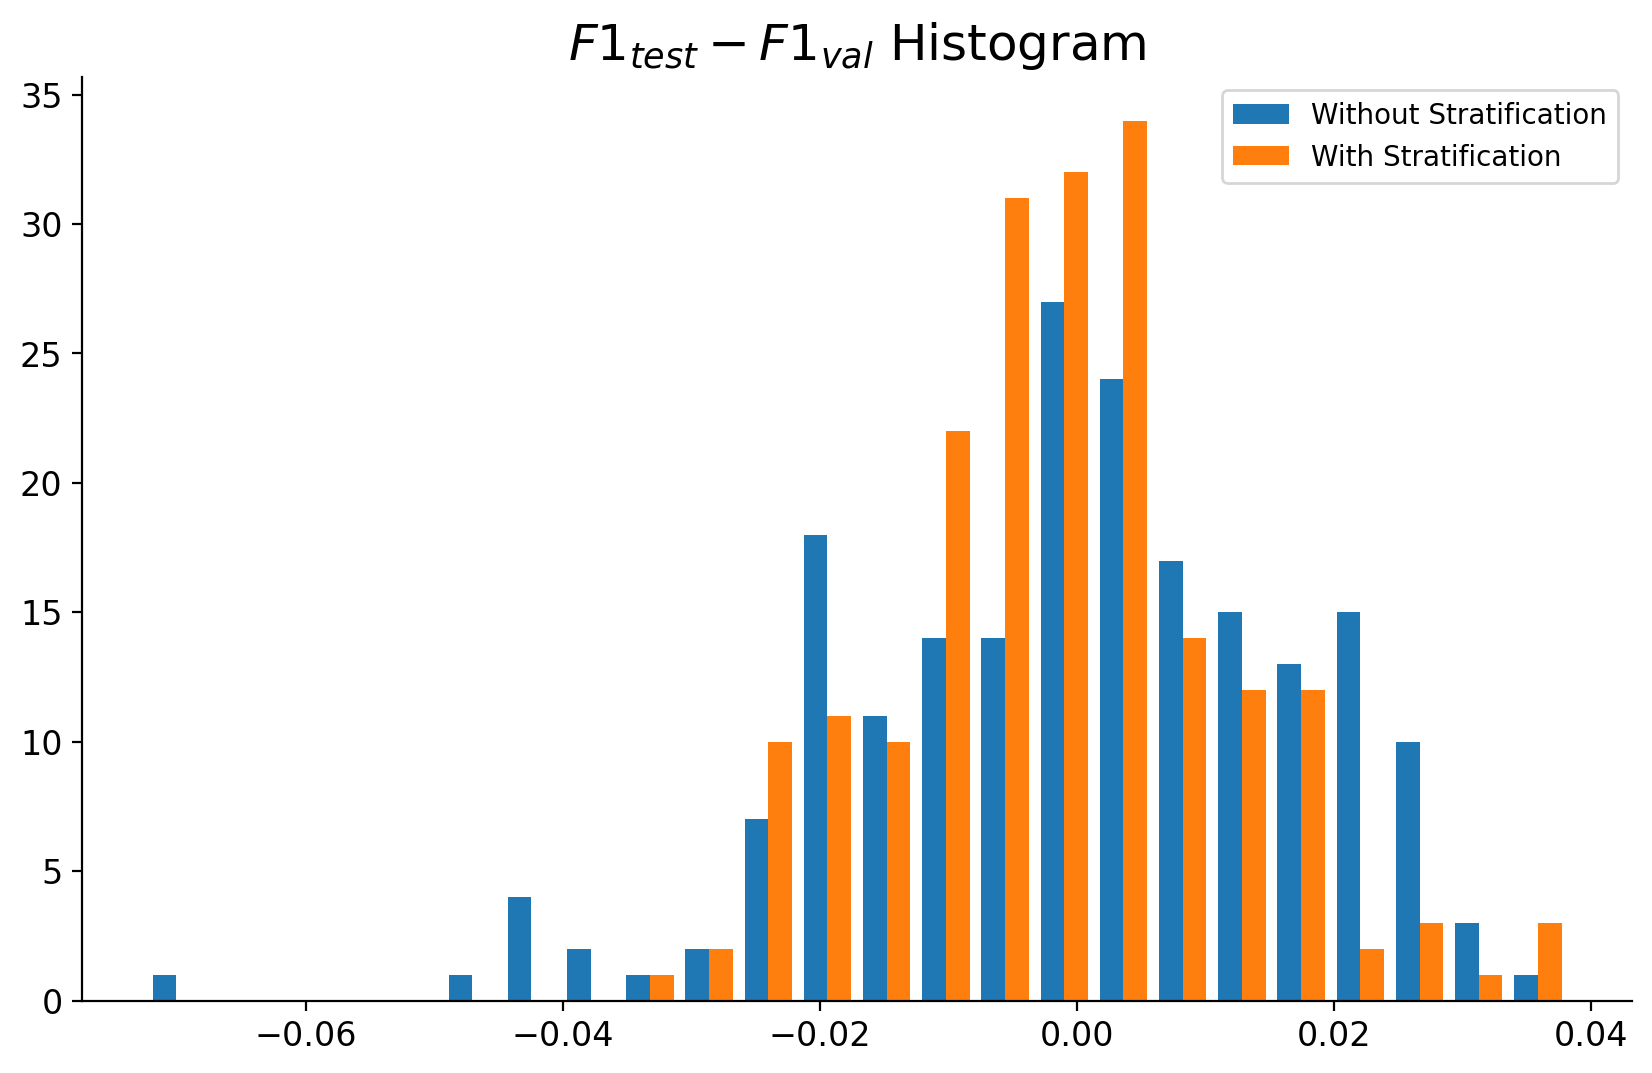

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
min_val = np.min((no_stratify_diffs, stratify_diffs))
max_val = np.max((no_stratify_diffs, stratify_diffs))
bins = np.linspace(min_val, max_val, 25)

ax.hist([no_stratify_diffs, stratify_diffs], bins=bins)

ax.legend(["Without Stratification", "With Stratification"])
ax.set_title(r"$F1_{test} - F1_{val}$ Histogram")
None

### Class Weight Shifts the Prediction Distribution

In [52]:
X_train, X_val, y_train, y_val = train_test_split(
    X_pretrain,
    y_pretrain,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_pretrain,
)

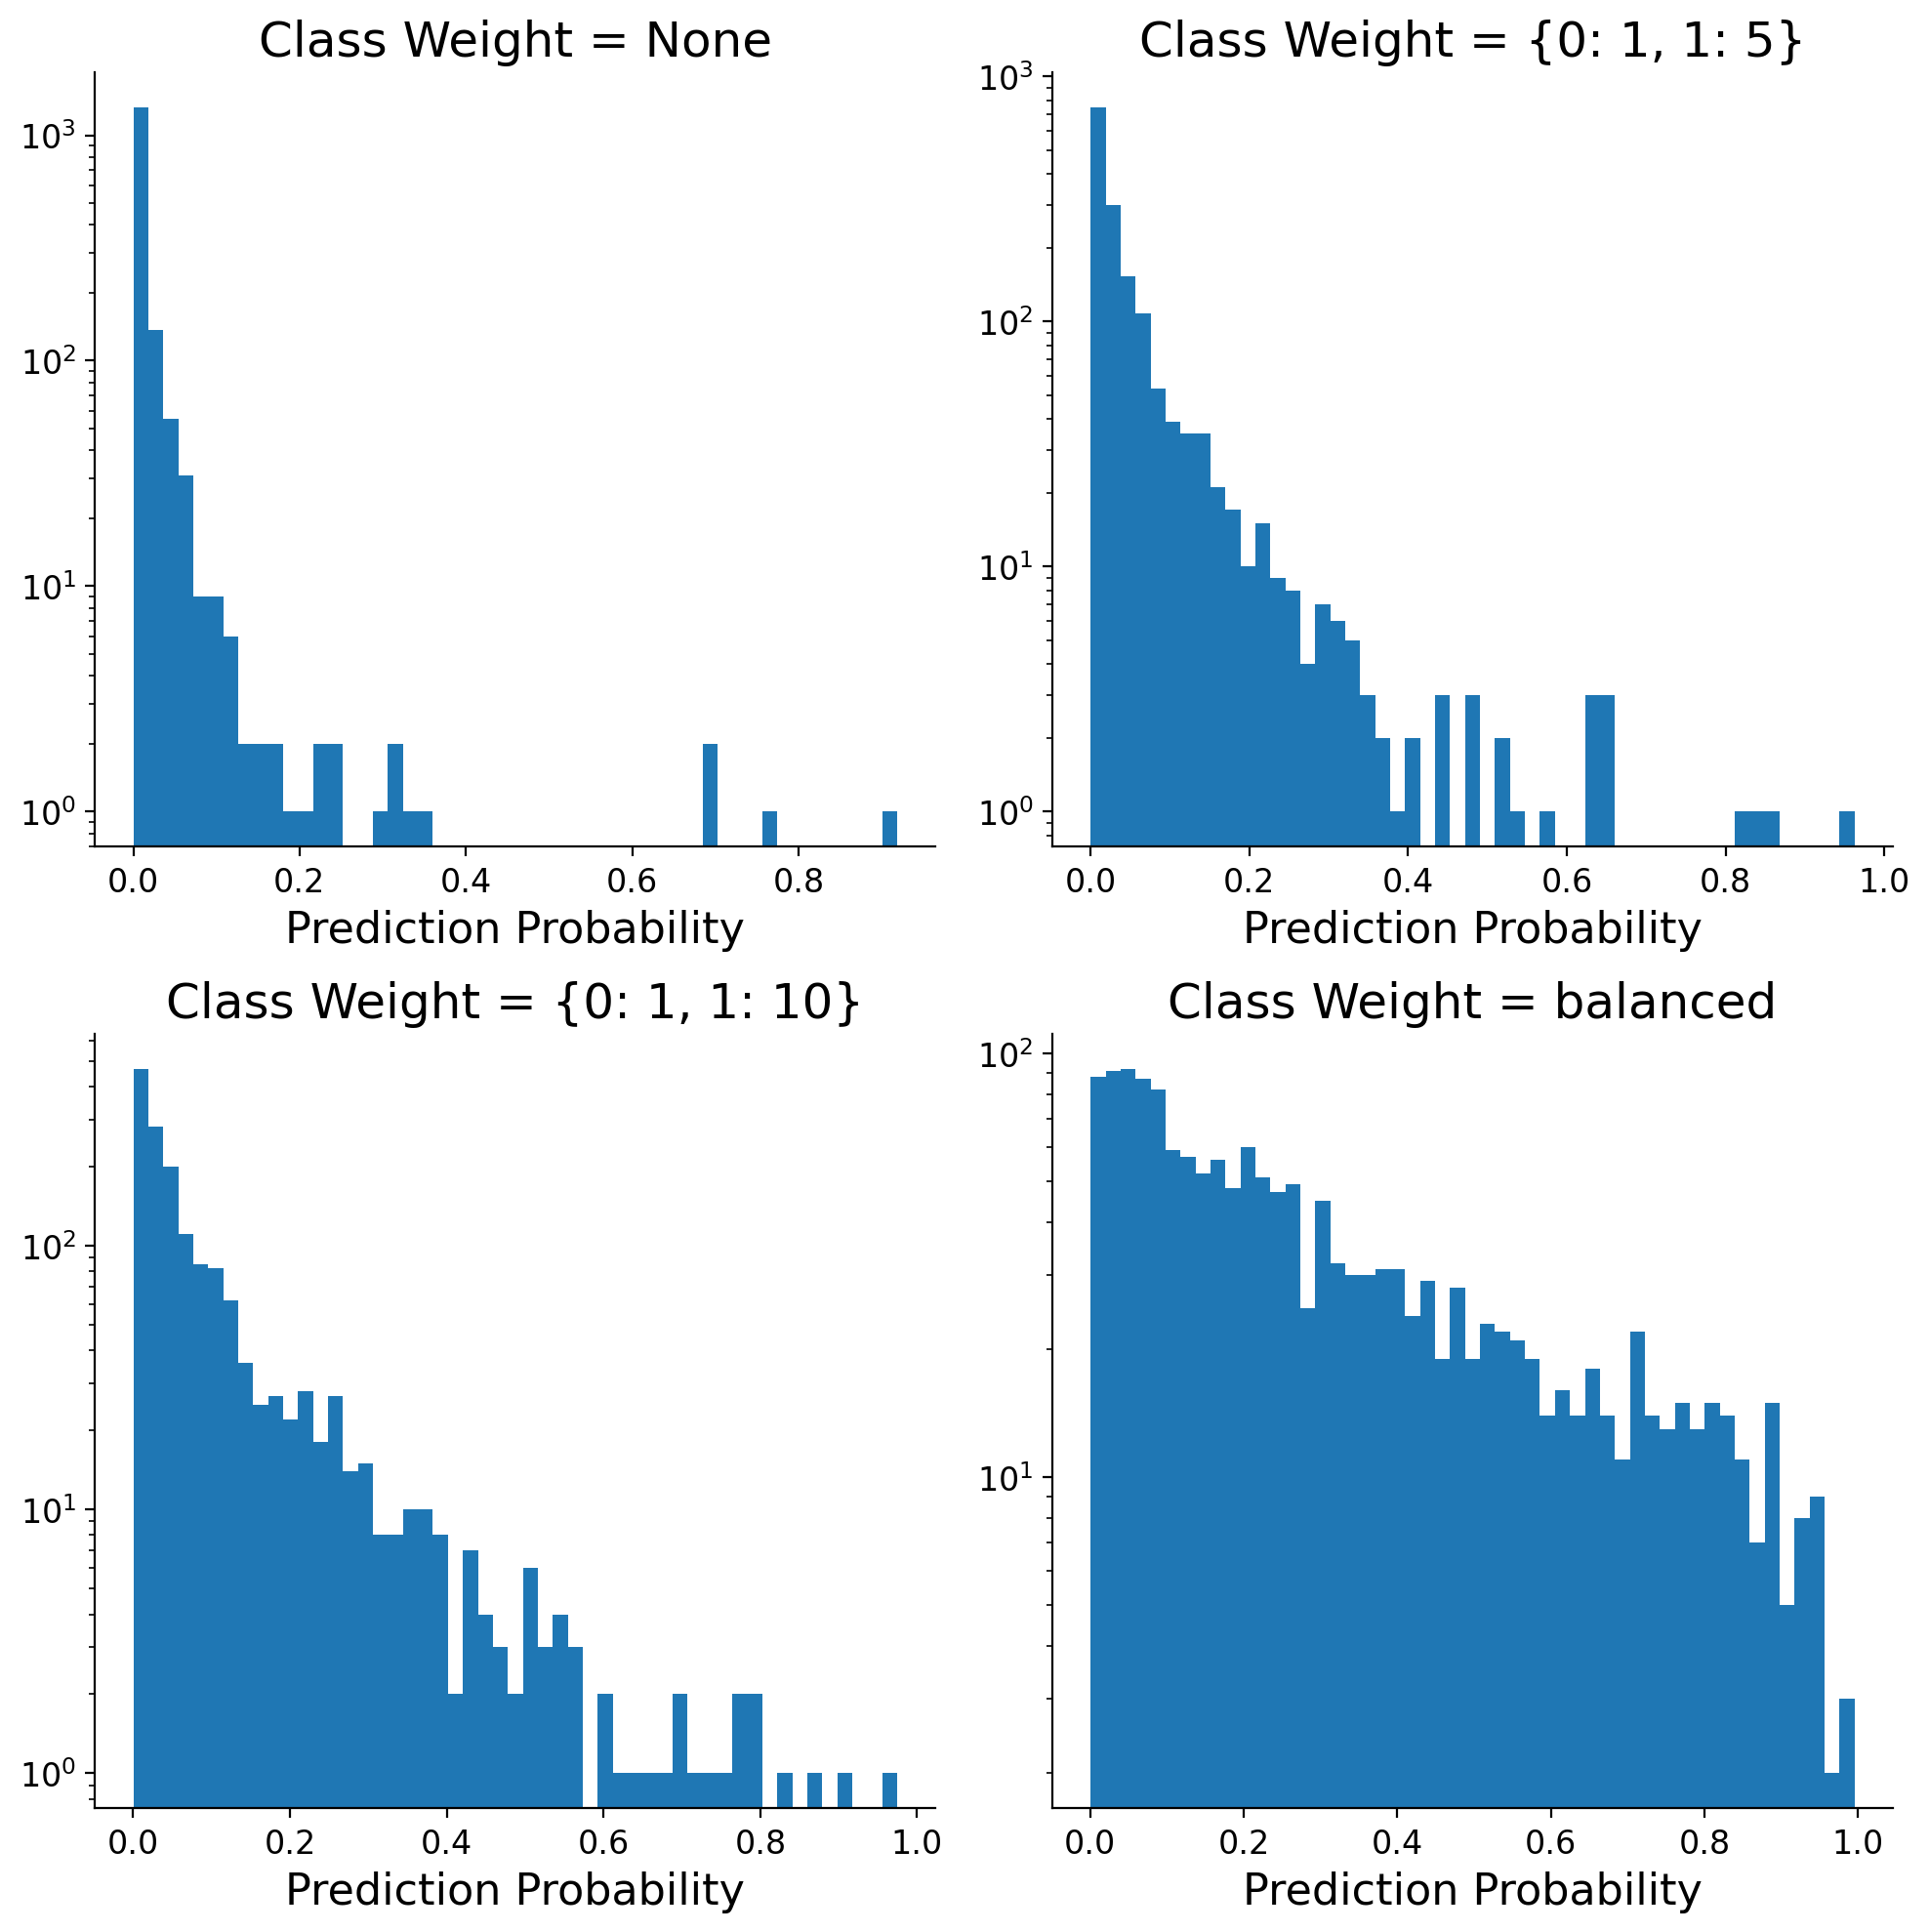

In [53]:
class_weights = (None, {0: 1, 1: 5}, {0: 1, 1: 10}, "balanced")
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
for ax, class_weight in zip(axs, class_weights):
    model = LogisticRegression(random_state=RANDOM_SEED, class_weight=class_weight)
    model.fit(X_train, y_train)
    ax.hist(model.predict_proba(X_val)[:, 1], bins=51)
    ax.semilogy()
    ax.set_title(f"Class Weight = {class_weight}")
    ax.set_xlabel("Prediction Probability")
    None

fig.tight_layout()

### why they're using different class weights and what the histograms represent.The histograms show the distribution of predicted probabilities for class 1. By using different class weights, the model's confidence in predicting class 1 changes. For example, higher weights on class 1 (like {0:1, 1:10}) make the model predict higher probabilities for class 1 instances, which could be visible in the histogram shifting right.

### With class_weight=None (no weighting), most predictions cluster near 0 (model is "unsure" about class 1)
### With class_weight={0:1, 1:10}, the histogram shift toward higher probabilities (model becomes more confident in class 1)

## Example output:
### You’ll see 4 histograms like this:

####    Left-top: class_weight=None → Most probabilities near 0.

####    Right-top: class_weight={0:1, 1:5} → More predictions near 0.5–1.

####    Left-bottom: class_weight={0:1, 1:10} → Even more high probabilities.

####    Right-bottom: "balanced" → Similar to manual weighting but automated.

#### This helps decide which weighting strategy best balances confidence and accuracy for the minority class.

In [54]:
from sklearn.metrics import precision_recall_curve

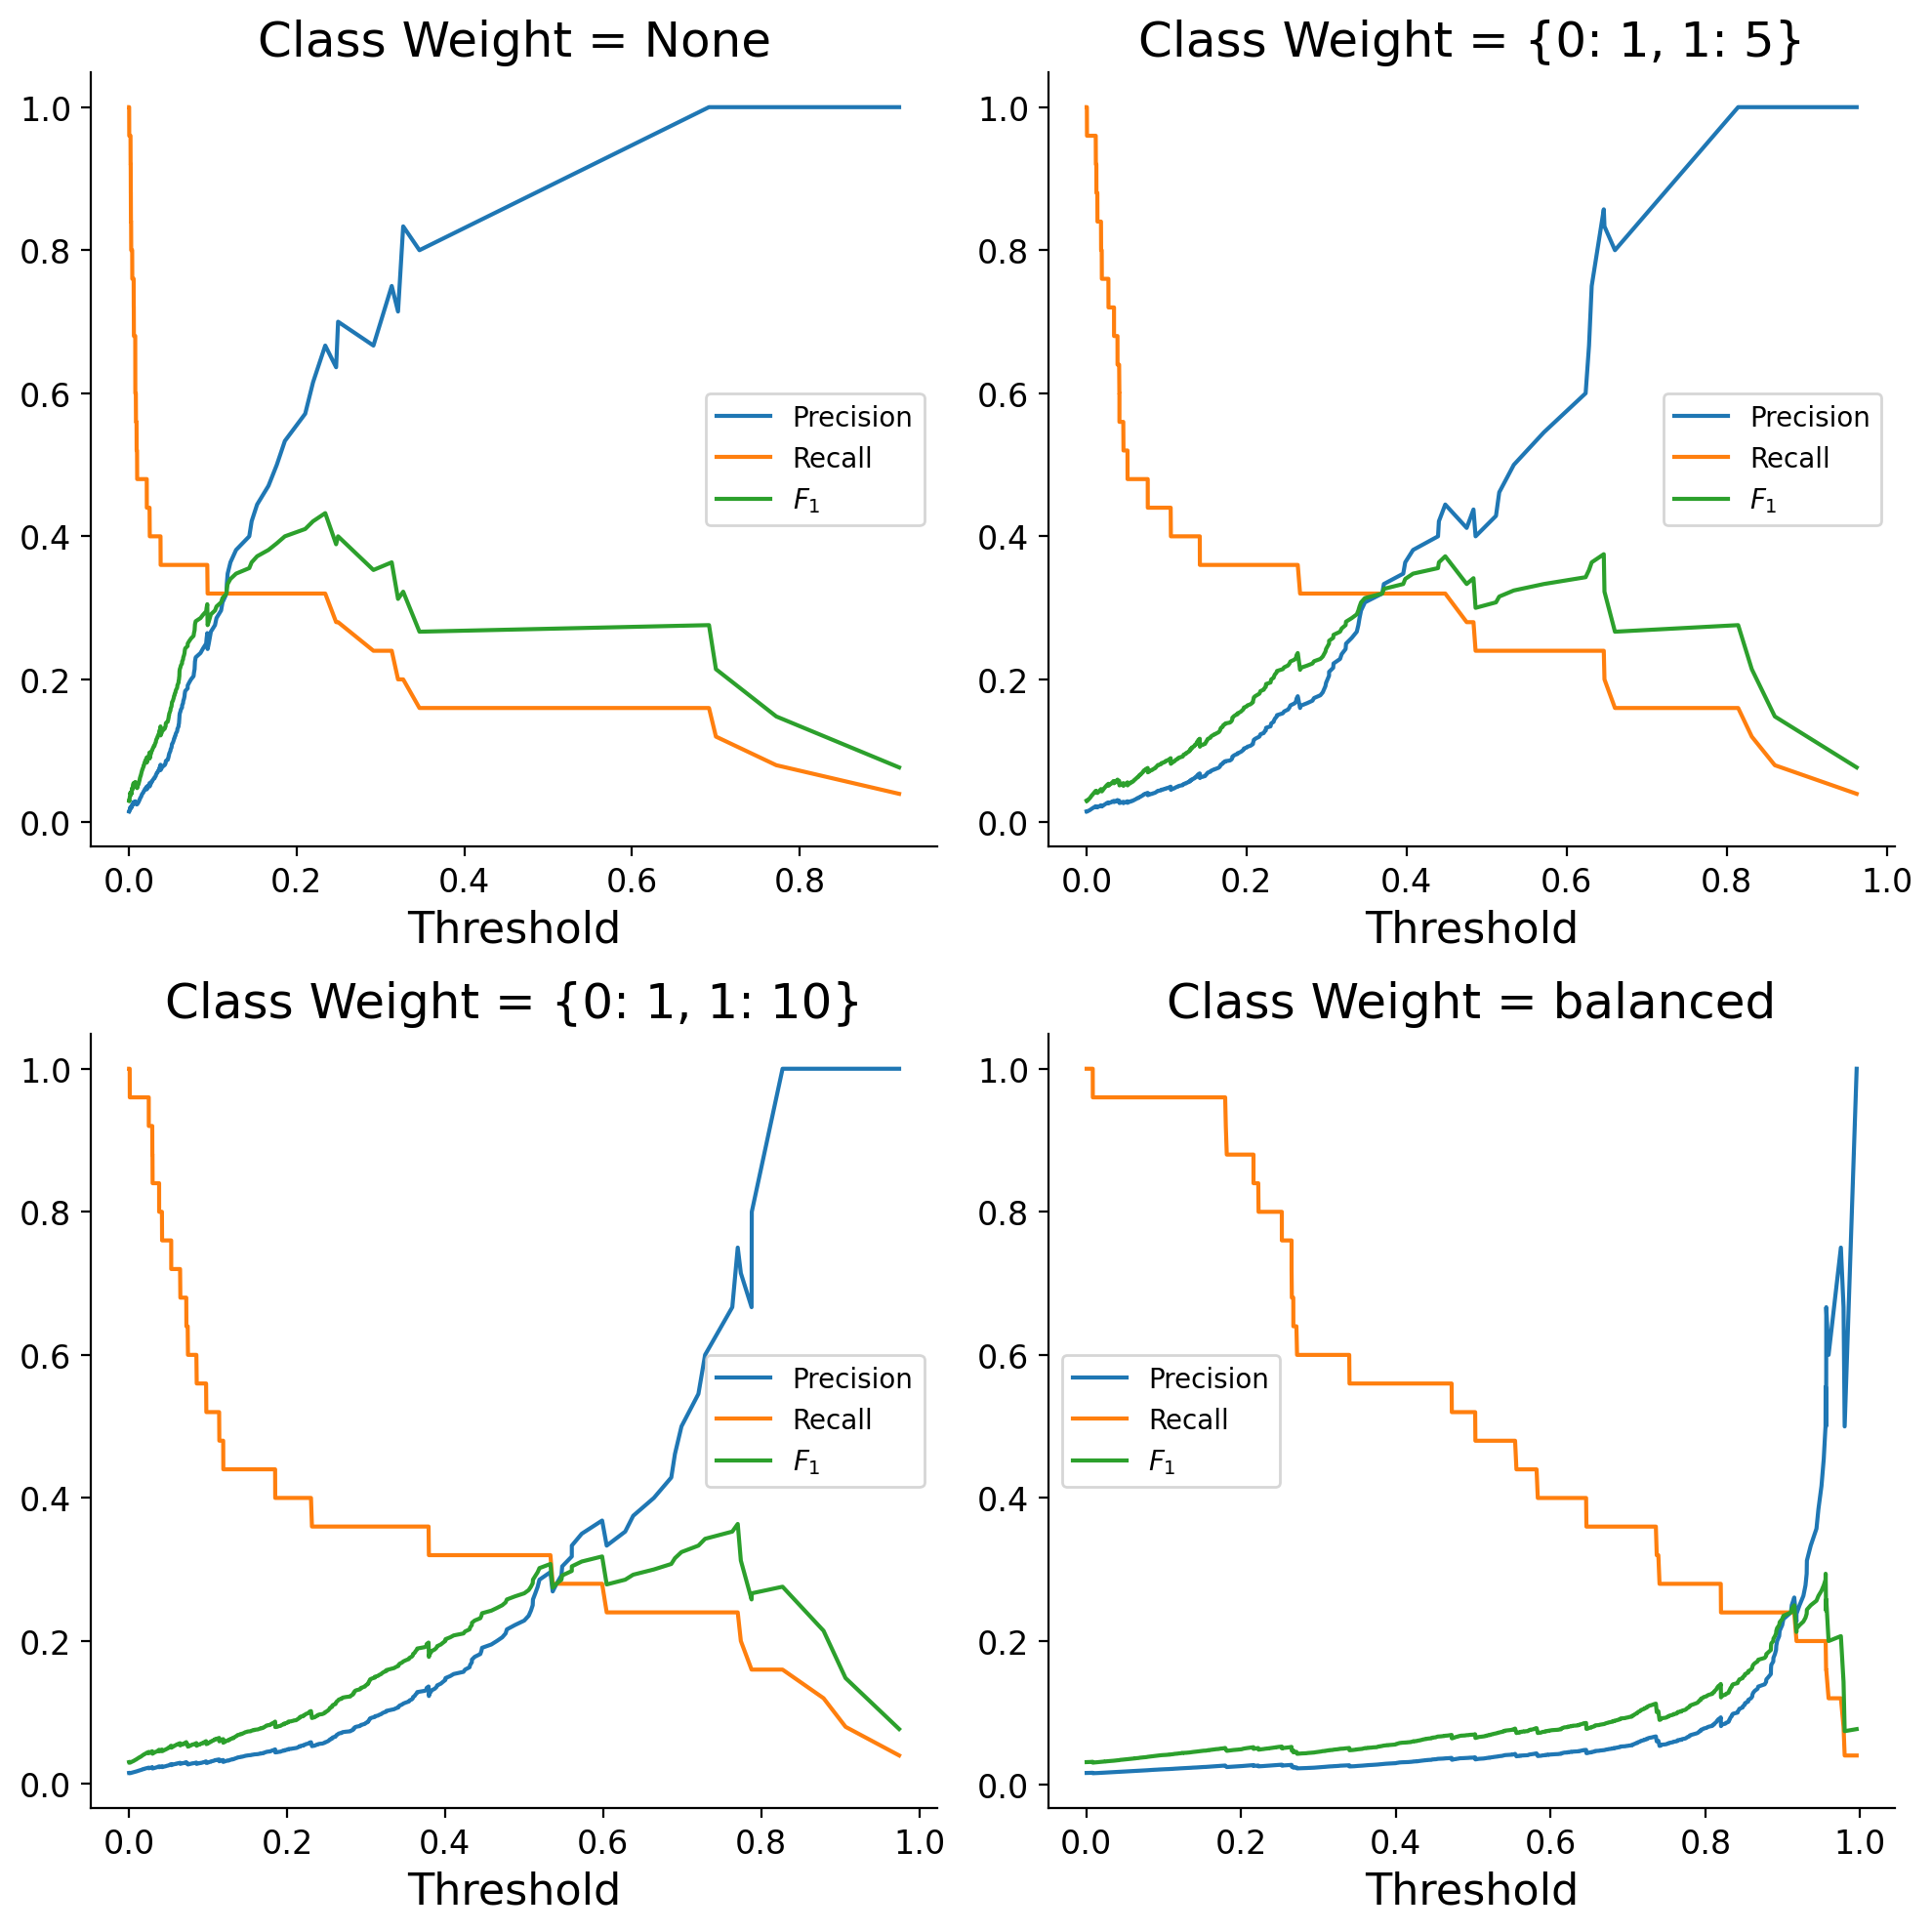

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
for ax, class_weight in zip(axs, class_weights):
    model = LogisticRegression(random_state=RANDOM_SEED, class_weight=class_weight)
    model.fit(X_train, y_train)
    precision, recall, thresholds = precision_recall_curve(
        y_val, model.predict_proba(X_val)[:, 1]
    )
    ax.plot(thresholds, precision[:-1])
    ax.plot(thresholds, recall[:-1])
    ax.plot(
        thresholds, 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1])
    )

    ax.legend(["Precision", "Recall", r"$F_{1}$"])
    ax.set_xlabel("Threshold")
    ax.set_title(f"Class Weight = {class_weight}")
    None

fig.tight_layout()

### Example Output:
### Each subplot will show curves like this:

###    X-axis: Threshold (from 0 to 1).

###    Y-axis: Precision/Recall/F1 values.

###    Interpretation:

###        If the F1 curve peaks at a low threshold (e.g., 0.3), the model works best when it’s "less strict" about classifying a sample as class 1.

###        Higher class weights for class 1 (e.g., {0:1, 1:10}) shift the recall curve upward, meaning the model detects more true positives.